In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.preprocessing import load_dataset, load_test_dataset
from src.data_pipeline import build_pipelines

print(f"TensorFlow version: {tf.__version__}")
print(f"Project root: {project_root}")

TensorFlow version: 2.21.0
Project root: C:\Users\Josh\Documents\TrafficSignRecognition


In [2]:
TRAIN_DIR = project_root / "data" / "Train"
TEST_CSV = project_root / "data" / "Test.csv"
TEST_DIR = project_root / "data"

X_train, y_train = load_dataset(str(TRAIN_DIR), img_size=32, use_clahe=True)
print(f"Train: X={X_train.shape}, y={y_train.shape}")

X_test, y_test = load_test_dataset(str(TEST_CSV), str(TEST_DIR), img_size=32, use_clahe=True)
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

Train: X=(39209, 32, 32, 3), y=(39209,)
Test:  X=(12630, 32, 32, 3), y=(12630,)


In [3]:
train_ds, val_ds, test_ds = build_pipelines(X_train, y_train, X_test, y_test)

print("Pipeline element specs:")
print(f"  train_ds: {train_ds.element_spec}")
print(f"  val_ds:   {val_ds.element_spec}")
print(f"  test_ds:  {test_ds.element_spec}")

print(f"\nNumber of batches:")
print(f"  train_ds: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"  val_ds:   {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"  test_ds:  {tf.data.experimental.cardinality(test_ds).numpy()}")

Pipeline element specs:
  train_ds: (TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
  val_ds:   (TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
  test_ds:  (TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Number of batches:
  train_ds: 491
  val_ds:   123
  test_ds:  198


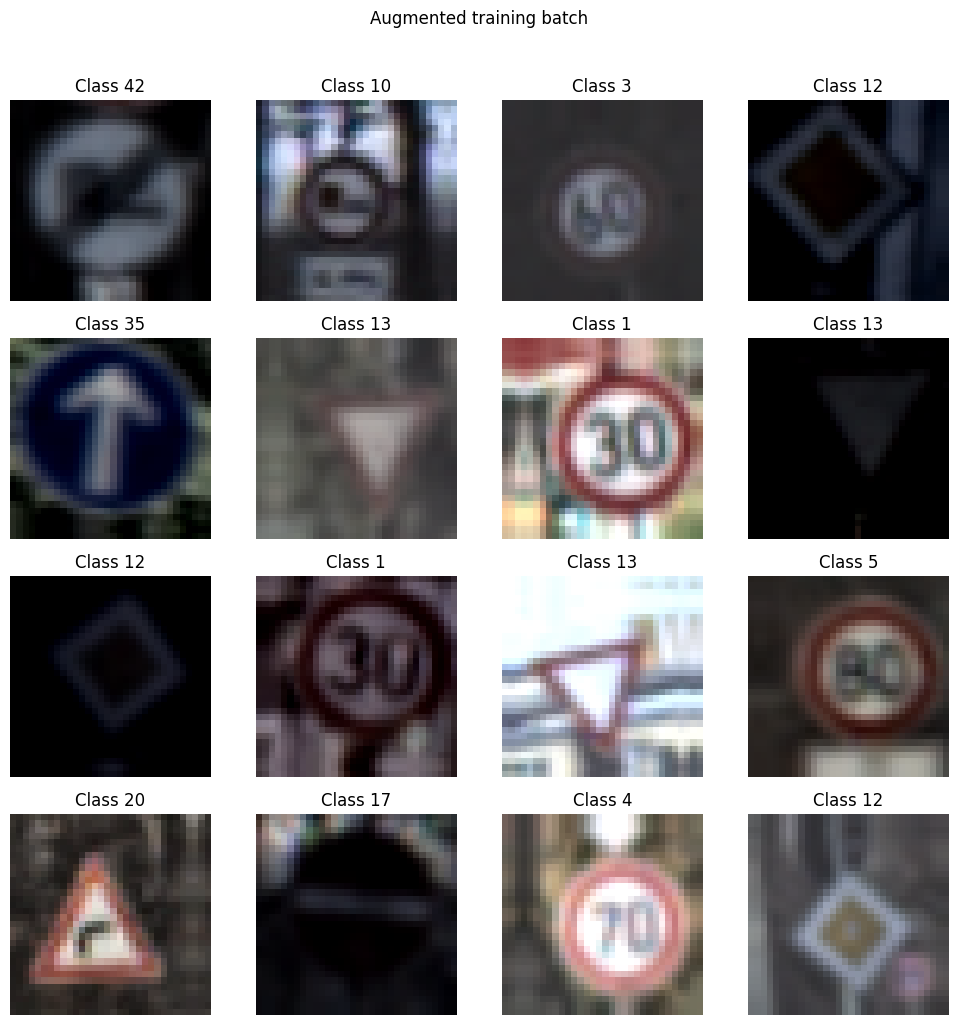

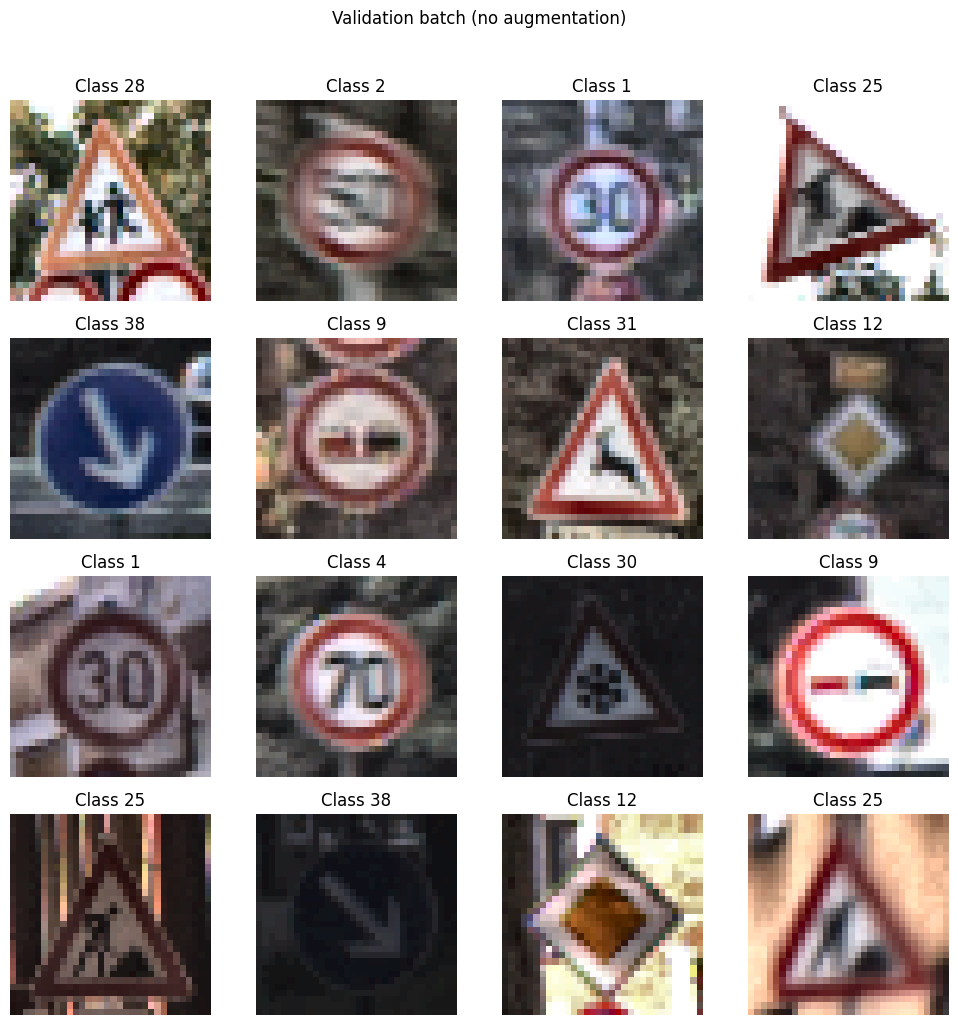

In [4]:
# Grab one batch from the training pipeline (will include augmentation)
for images, labels in train_ds.take(1):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(images[i].numpy(), 0, 1))  # clip in case brightness aug went out of [0,1]
        ax.set_title(f"Class {labels[i].numpy()}")
        ax.axis('off')
    plt.suptitle("Augmented training batch", y=1.02)
    plt.tight_layout()
    plt.show()
    break

# Compare to validation (no augmentation)
for images, labels in val_ds.take(1):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(images[i].numpy(), 0, 1))
        ax.set_title(f"Class {labels[i].numpy()}")
        ax.axis('off')
    plt.suptitle("Validation batch (no augmentation)", y=1.02)
    plt.tight_layout()
    plt.show()
    break